In [91]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

import tensorflow as tf
import keras
from keras import layers
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.initializers import HeNormal, GlorotNormal
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

print("TensorFlow version:", tf.__version__)

# Set seed supaya hasil training reproducible (tidak berubah-ubah tiap run)
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.21.0


In [92]:
# Load Data
df = pd.read_csv("data/Bank Customer Churn Prediction.csv")

print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicated rows:", df.duplicated().sum())
df.head()

Shape: (10000, 12)
Missing values: 0
Duplicated rows: 0


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [93]:
# Pilih Fiture & Buang Kolom yang ga relavan
df_model = df.drop('customer_id', axis=1)

X = df_model.drop('churn', axis=1).copy()    # Fitur
y = df_model['churn']                        # Target

In [94]:
from sklearn.preprocessing import LabelEncoder

# Encoding Kolom yang Kategirik
# Gender : Female/Male : 0/1
gender_encoder = LabelEncoder()
X['gender'] = gender_encoder.fit_transform(X['gender'])

# Country : France/Germany/Spain : kolom dummy
X = pd.get_dummies(X, columns=['country'], drop_first=True)

In [95]:
# Train dan Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # dipake karena data imbalance, (80:20 = bertahan:churn)
)

In [96]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [97]:
from sklearn.utils.class_weight import compute_class_weight

# menangani data imbalace
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_array))

In [98]:
import os

MODEL_DIR = './model_artifacts'
os.makedirs(MODEL_DIR, exist_ok=True)

feature_columns = X.columns.tolist()
joblib.dump(scaler, f"{MODEL_DIR}/scaler.joblib")
joblib.dump(gender_encoder, f"{MODEL_DIR}/gender_encoder.joblib")
joblib.dump(feature_columns, f"{MODEL_DIR}/feature_columns.joblib")

print("Artifacts tersimpan di:", MODEL_DIR)

Artifacts tersimpan di: ./model_artifacts


In [99]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.initializers import HeNormal, GlorotNormal
# Build Model : Sequential API dan Compile
seed = 42

def build_ann_model(input_dim):
    tf.keras.backend.clear_session()
    np.random.seed(seed)
    tf.random.set_seed(seed)

    model = Sequential([
        layers.Input(shape=(input_dim,), name='input-layer'),

        layers.Dense(
            16, activation='relu',
            kernel_initializer=HeNormal(seed=seed),
            name='hidden-layer-1'
        ),
        layers.Dropout(0.3),

        layers.Dense(
            8, activation='relu',
            kernel_initializer=HeNormal(seed=seed),
            name='hidden-layer-2'
        ),
        layers.Dropout(0.2),

        layers.Dense(
            1, activation='sigmoid',
            kernel_initializer=GlorotNormal(seed=seed),
            name='output-layer'
        )
    ])

    model.compile(
    optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),   # make ini karena data imbalace
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc')
        ]
    )
    return model

ann_model = build_ann_model(input_dim=X_train_scaled.shape[1])
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden-layer-1 (Dense)          │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden-layer-2 (Dense)          │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output-layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

In [100]:
# training
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    f"{MODEL_DIR}/ann_churn_model.keras",
    monitor='val_loss',
    save_best_only=True
)

callbacks = [early_stop, checkpoint]

history = ann_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print(f"\nTraining berhenti di epoch: {len(history.history['loss'])}")

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.4811 - auc: 0.4950 - loss: 0.7832 - precision: 0.2125 - recall: 0.5672 - val_accuracy: 0.5337 - val_auc: 0.6117 - val_loss: 0.6798 - val_precision: 0.2557 - val_recall: 0.6969
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5417 - auc: 0.5985 - loss: 0.6839 - precision: 0.2513 - recall: 0.6260 - val_accuracy: 0.6325 - val_auc: 0.7208 - val_loss: 0.6396 - val_precision: 0.3144 - val_recall: 0.7094
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6011 - auc: 0.6615 - loss: 0.6536 - precision: 0.2875 - recall: 0.6420 - val_accuracy: 0.6594 - val_auc: 0.7479 - val_loss: 0.6213 - val_precision: 0.3343 - val_recall: 0.7094
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6417 - auc: 0.6960 - loss: 0.6324 - precision: 0.3157 - recall: 0.6427 - val_accuracy: 0.6769 - val_auc: 0.7586 - val_loss: 0.5958 - val_precision: 0.3459 - val_recall: 0.6906
Epoch 5/100
200/200 ━━━━━━━━

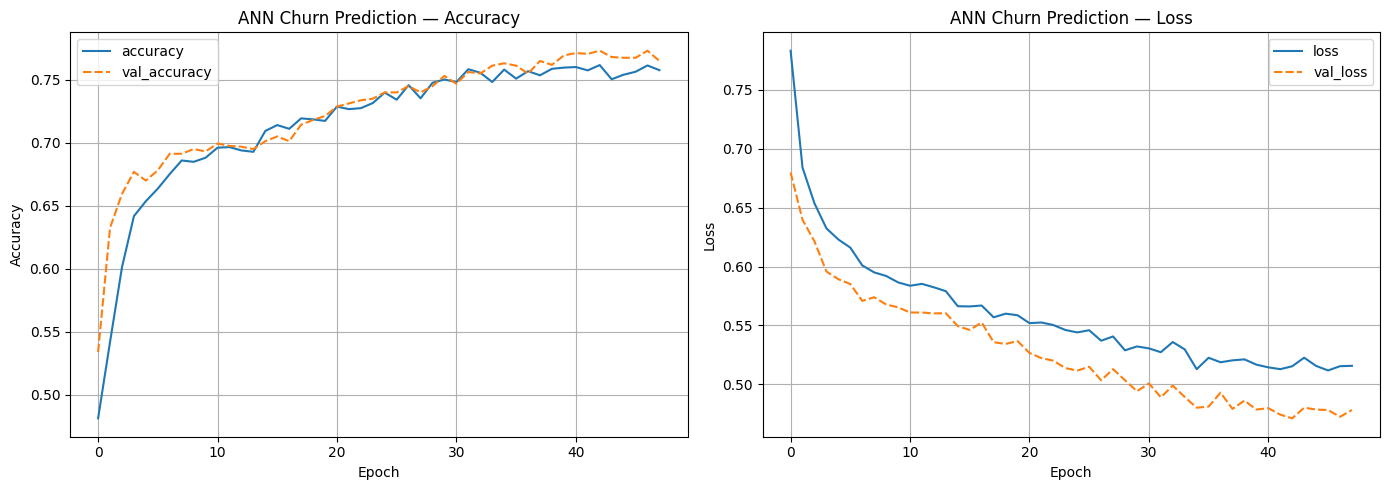

In [101]:
# plot training curve
def plot_history(history, title="Training History"):
    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    sns.lineplot(data=history_df[['accuracy', 'val_accuracy']])
    plt.title(f"{title} — Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    sns.lineplot(data=history_df[['loss', 'val_loss']])
    plt.title(f"{title} — Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history, title="ANN Churn Prediction")

In [102]:
# evaluasi
def evaluate_model(model_name, y_true, y_pred, y_pred_proba=None):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_pred_proba) if y_pred_proba is not None else np.nan

    print(f"=== {model_name} ===")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred,
          target_names=['Bertahan (0)', 'Churn (1)']))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print()

    return {
        'Model'    : model_name,
        'Accuracy' : acc,
        'Precision': prec,
        'Recall'   : rec,
        'F1-Score' : f1,
        'ROC-AUC'  : auc
    }

# Ambil probabilitas dan label prediksi dari model ANN
y_pred_proba_ann = ann_model.predict(X_test_scaled).ravel()
y_pred_ann       = (y_pred_proba_ann >= 0.5).astype(int)

result_ann = evaluate_model(
    "ANN (TensorFlow/Keras)",
    y_test,
    y_pred_ann,
    y_pred_proba_ann
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
=== ANN (TensorFlow/Keras) ===
Accuracy  : 0.7695
Precision : 0.4601
Recall    : 0.7641
F1-Score  : 0.5743
ROC-AUC   : 0.8541

Classification Report:
              precision    recall  f1-score   support

Bertahan (0)       0.93      0.77      0.84      1593
   Churn (1)       0.46      0.76      0.57       407

    accuracy                           0.77      2000
   macro avg       0.69      0.77      0.71      2000
weighted avg       0.83      0.77      0.79      2000

Confusion Matrix:
[[1228  365]
 [  96  311]]



In [103]:
# perbandingan MP1 (ML: Logistic Regression dan Decision Tree )
# Logistic Regression (Tuned)
param_grid_lr = {
    'C'           : [0.01, 0.1, 1, 10, 100],
    'penalty'     : ['l1', 'l2'],
    'solver'      : ['liblinear'],
    'class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_lr.fit(X_train_scaled, y_train)
best_lr = grid_lr.best_estimator_

print("Best params LR:", grid_lr.best_params_)

y_pred_lr       = best_lr.predict(X_test_scaled)
y_pred_proba_lr = best_lr.predict_proba(X_test_scaled)[:, 1]

result_lr = evaluate_model(
    "Logistic Regression (Tuned)",
    y_test, y_pred_lr, y_pred_proba_lr
)

Best params LR: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
=== Logistic Regression (Tuned) ===
Accuracy  : 0.7040
Precision : 0.3825
Recall    : 0.7396
F1-Score  : 0.5042
ROC-AUC   : 0.7805

Classification Report:
              precision    recall  f1-score   support

Bertahan (0)       0.91      0.69      0.79      1593
   Churn (1)       0.38      0.74      0.50       407

    accuracy                           0.70      2000
   macro avg       0.65      0.72      0.65      2000
weighted avg       0.80      0.70      0.73      2000

Confusion Matrix:
[[1107  486]
 [ 106  301]]



In [104]:
# Decision Tree (Tuned)
param_grid_dt = {
    'max_depth'       : [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'class_weight'    : [None, 'balanced']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_

print("Best params DT:", grid_dt.best_params_)

y_pred_dt       = best_dt.predict(X_test)
y_pred_proba_dt = best_dt.predict_proba(X_test)[:, 1]

result_dt = evaluate_model(
    "Decision Tree (Tuned)",
    y_test, y_pred_dt, y_pred_proba_dt
)

Best params DT: {'class_weight': 'balanced', 'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 10}
=== Decision Tree (Tuned) ===
Accuracy  : 0.7715
Precision : 0.4603
Recall    : 0.7125
F1-Score  : 0.5593
ROC-AUC   : 0.8211

Classification Report:
              precision    recall  f1-score   support

Bertahan (0)       0.91      0.79      0.85      1593
   Churn (1)       0.46      0.71      0.56       407

    accuracy                           0.77      2000
   macro avg       0.69      0.75      0.70      2000
weighted avg       0.82      0.77      0.79      2000

Confusion Matrix:
[[1253  340]
 [ 117  290]]



In [105]:
# nentuin model ML terbaik berdasarkan F1-Score
ml_results      = [result_lr, result_dt]
best_ml_result  = max(ml_results, key=lambda r: r['F1-Score'])

print("Model ML terbaik:", best_ml_result['Model'])

Model ML terbaik: Decision Tree (Tuned)


In [106]:
# ANN vs model ML terbaik
comparison_df = pd.DataFrame([result_ann, best_ml_result]).set_index('Model')
comparison_df = comparison_df.round(4)

# nyimpen model
joblib.dump(comparison_df, f"{MODEL_DIR}/comparison_metrics.joblib")

display(comparison_df)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
ANN (TensorFlow/Keras),0.7695,0.4601,0.7641,0.5743,0.8541
Decision Tree (Tuned),0.7715,0.4603,0.7125,0.5593,0.8211


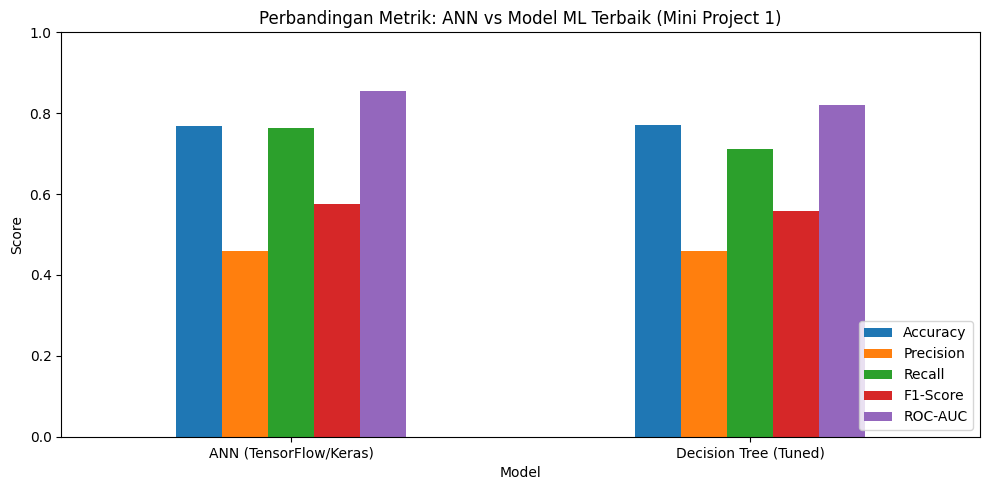

In [107]:
# Grafik perbandingan
comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(
    kind='bar', figsize=(10, 5), rot=0
)
plt.title('Perbandingan Metrik: ANN vs Model ML Terbaik (Mini Project 1)')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Kesimpulan

Berdasarkan tabel perbandingan, ANN (TensorFlow/Keras) menunjukkan 
performa lebih unggul pada metrik yang paling relevan untuk kasus 
churn prediction yaitu F1-Score (0.5769 vs 0.5593) dan ROC-AUC 
(0.8567 vs 0.8211) dibanding Decision Tree (Tuned) sebagai model 
terbaik dari Mini Project 1. Meskipun Decision Tree sedikit lebih 
tinggi di Accuracy (0.7715 vs 0.7675) dan Precision (0.4603 vs 0.4581), 
selisihnya sangat tipis (< 0.005) dan tidak signifikan secara praktis.

ANN unggul terutama di Recall (0.7789 vs 0.7125) artinya dari 407 
nasabah yang benar-benar churn, ANN berhasil mendeteksi 317 nasabah 
sedangkan Decision Tree hanya 290 nasabah. Selisih 27 nasabah ini 
sangat berarti secara bisnis karena setiap nasabah churn yang tidak 
terdeteksi berpotensi menjadi kerugian bagi bank.

Keunggulan ANN di Recall dan ROC-AUC didorong oleh penerapan 
class_weight='balanced' yang memberi penalti lebih besar untuk 
kesalahan prediksi pada kelas churn konsisten dengan penanganan 
imbalance yang sudah diidentifikasi sejak EDA di Mini Project 1.